# Clusterización temática de artículos (TF-IDF → LSA → K-means)

**Objetivo Específico 3** — Determinar la estructura temática latente de los artículos publicados en la
Chilean Journal of Statistics (2010–2025) mediante técnicas de agrupamiento no supervisado.

Este notebook reproduce íntegramente el pipeline descrito en la Sección 4.4 de la tesis:

1. Construcción y preprocesamiento del corpus
2. Representación vectorial (TF-IDF)
3. Reducción semántica (LSA / Truncated SVD)
4. Selección del número óptimo de clusters (k)
5. Modelo final K-means
6. Interpretación de clusters (términos representativos, artículos prototípicos)
7. Validación de robustez (bootstrap re-clustering, comparación con DBSCAN y clustering jerárquico)
8. Evolución temporal y cruces geográfico-institucionales

> **Nota sobre k:** la solución final reportada en la tesis usa **k = 7**, seleccionado por la
> convergencia simultánea de tres métricas de validación interna (Silhouette, Calinski-Harabasz,
> Davies-Bouldin) sobre el rango k ∈ [3, 15]. Ver Sección 4 de este notebook para el detalle completo
> de la justificación estadística.


## 0. Configuración e imports

In [1]:

from pathlib import Path
import json, re, unicodedata

import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                              davies_bouldin_score, adjusted_rand_score,
                              pairwise_distances_argmin_min)
from sklearn.linear_model import LinearRegression
from scipy.optimize import linear_sum_assignment
from dateutil import parser as dtparser

import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
try:
    stopwords.words("english")
except LookupError:
    nltk.download("stopwords")

RANDOM_STATE = 42
DATA_JSON = Path("../data/reorganized_data_c_CLEAN_NORMALIZADO.json")
TABLES_DIR = Path("../results/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path("../results/figures"); FIGS_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_JSON, "r", encoding="utf-8") as f:
    records = json.load(f)

print(f"Artículos cargados: {len(records)}")


Artículos cargados: 177


## 1. Construcción y preprocesamiento del corpus

Para cada artículo se concatena **título + resumen + palabras clave** (campo `Articulo`, `abstract`,
`keywords` en el JSON — nótese que el campo `Titulo` corresponde al título del *volumen/número*, no
del artículo individual, y por lo tanto no se usa aquí). El texto se normaliza (minúsculas, sin
acentos), se tokeniza, se eliminan stopwords en español e inglés más una lista específica de
autores/instituciones (para evitar que nombres propios contaminen los clusters), y se aplica stemming
(Snowball, inglés).


In [2]:

def strip_accents(s: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))

def simple_tokenize(text: str):
    return re.findall(r"[A-Za-zÀ-ÖØ-öø-ÿ]+", text)

def build_stopwords():
    en = set(stopwords.words("english"))
    es = set(stopwords.words("spanish"))
    base = en | es
    noacc = {strip_accents(w) for w in base}
    extra = {"et", "al", "via", "doi", "preprint", "article", "study",
             "journal", "revista", "volume", "issue", "http", "https"}
    return {w.lower() for w in (base | noacc | extra)}

def build_metadata_stoplist(records):
    names, unis = set(), set()
    for rec in records:
        for a in rec.get("Autores") or []:
            if isinstance(a, dict):
                if a.get("nombre"):
                    names.add(a["nombre"])
                if a.get("universidad"):
                    unis.add(a["universidad"])
    toks = set()
    for t in list(names) + list(unis):
        for tok in simple_tokenize(str(t)):
            tok = strip_accents(tok).lower()
            if len(tok) >= 2:
                toks.add(tok)
    return toks

def preprocess_text(text, stop_all, stemmer, extra_exclusions):
    if not isinstance(text, str):
        text = ""
    t = strip_accents(text.lower())
    tokens = simple_tokenize(t)
    clean = []
    for tok in tokens:
        if len(tok) < 2 or tok in stop_all or tok in extra_exclusions:
            continue
        clean.append(stemmer.stem(tok))
    return " ".join(clean)

stop_all = build_stopwords()
extra_exclusions = build_metadata_stoplist(records)
stemmer = SnowballStemmer("english")

def get_year(fecha):
    try:
        return dtparser.parse(str(fecha), fuzzy=True).year
    except Exception:
        for tok in re.split(r"[,\s/]+", str(fecha)):
            if tok.isdigit() and 1900 <= int(tok) <= 2100:
                return int(tok)
    return np.nan

rows = []
for i, rec in enumerate(records):
    title = rec.get("Articulo", "")          # título REAL del artículo (no "Titulo", que es el del volumen)
    abstr = rec.get("abstract", "") or ""
    keyws = rec.get("keywords") or ""
    if isinstance(keyws, list):
        keyws = ", ".join(str(k) for k in keyws)
    text_raw = " ".join([x for x in [title, abstr, keyws] if isinstance(x, str)])
    rows.append({
        "doc_id": i,
        "year": get_year(rec.get("fecha")),
        "title": title,
        "text_clean": preprocess_text(text_raw, stop_all, stemmer, extra_exclusions),
    })

df = pd.DataFrame(rows)
df["n_tokens"] = df["text_clean"].str.split().apply(len)
print(df[["n_tokens"]].describe())
df.head()


         n_tokens
count  177.000000
mean    93.361582
std     34.000406
min     21.000000
25%     72.000000
50%     89.000000
75%    112.000000
max    228.000000


,doc_id,year,title,text_clean,n_tokens
0,0,2010,Pilar Iglesias: A life of contributions to sta...,life contribut intend give idea larg impact zu...,51
1,1,2010,Multivariate unified skew-elliptical distribut...,multivari unifi skew ellipt distribut class mu...,52
2,2,2010,Some thoughts on the Bayesian robustness of lo...,thought bayesian robust locat scale model pape...,40
3,3,2010,Bayesian modeling of flash floods using genera...,bayesian model flash flood use general extrem ...,228
4,4,2010,Significance test for comparing digital gene e...,signific test compar digit gene express profil...,119


## 2. Representación vectorial: TF-IDF

In [3]:

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95)
X_tfidf = vectorizer.fit_transform(df["text_clean"].tolist())
vocab = np.array(vectorizer.get_feature_names_out())

print(f"Matriz TF-IDF: {X_tfidf.shape[0]} documentos x {X_tfidf.shape[1]} términos, "
      f"{X_tfidf.nnz} entradas no nulas (densidad ≈ {X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1]) * 100:.1f}%)")


Matriz TF-IDF: 177 documentos x 1247 términos, 11175 entradas no nulas (densidad ≈ 5.1%)


### Figuras de diagnóstico del corpus (Figuras 4.23 y 4.24)

A partir del corpus preprocesado se generan dos visualizaciones de diagnóstico citadas en la
Sección 4.4 de la tesis: el gráfico de términos más frecuentes (Figura 4.23) y la nube de palabras
(Figura 4.24). Ambas se construyen sobre las frecuencias de tokens del texto ya limpio y estemizado.


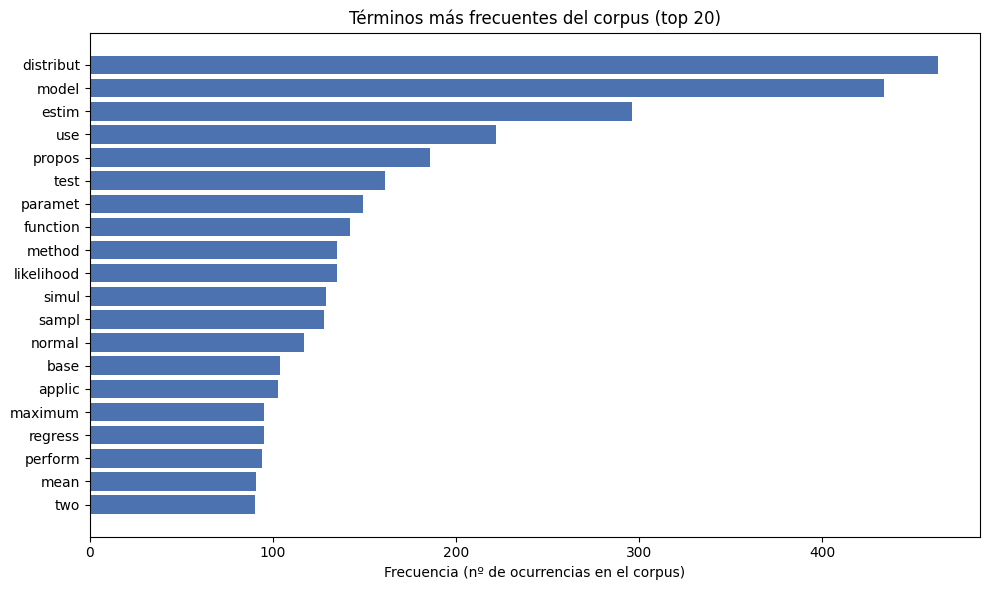

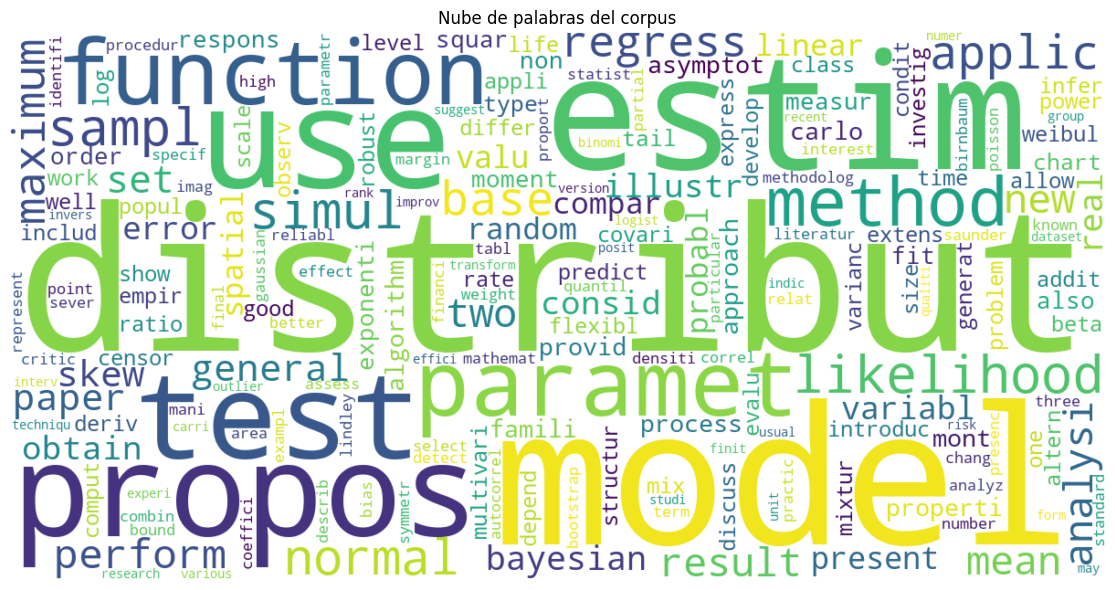

In [4]:

from collections import Counter
from wordcloud import WordCloud

# Frecuencia de términos sobre el corpus preprocesado (tokens de text_clean)
token_counter = Counter()
for txt in df["text_clean"]:
    token_counter.update(txt.split())

# --- Figura 4.23: términos más frecuentes ---
TOP_N = 20
terms, freqs = zip(*token_counter.most_common(TOP_N))
y = np.arange(len(terms))[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y, freqs, color="#4c72b0")
ax.set_yticks(y)
ax.set_yticklabels(terms)
ax.set_xlabel("Frecuencia (nº de ocurrencias en el corpus)")
ax.set_title(f"Términos más frecuentes del corpus (top {TOP_N})")
fig.tight_layout()
fig.savefig(FIGS_DIR / "fig_4_23_top_terms.png", dpi=160)
plt.show()

# --- Figura 4.24: nube de palabras ---
wc = WordCloud(width=1200, height=600, background_color="white",
               max_words=200, collocations=False).generate_from_frequencies(token_counter)
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras del corpus")
fig.tight_layout()
fig.savefig(FIGS_DIR / "fig_4_24_wordcloud.png", dpi=160)
plt.show()


## 3. Reducción semántica: LSA (Truncated SVD)

In [5]:

n_components = min(200, X_tfidf.shape[0] - 1)   # r <= N-1 => r = 176
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
Z = svd.fit_transform(X_tfidf)

print(f"Espacio latente Z: {Z.shape}, varianza explicada acumulada ≈ {svd.explained_variance_ratio_.sum():.3f}")


Espacio latente Z: (177, 176), varianza explicada acumulada ≈ 0.999


## 4. Selección del número óptimo de clusters (k)

Se evalúa K-means sobre el espacio LSA para k ∈ [3, 15], reportando tres métricas de validación
interna complementarias: **Silhouette** (↑ mejor), **Calinski-Harabasz** (↑ mejor) y
**Davies-Bouldin** (↓ mejor). Esta es la Tabla 4.4 de la tesis.


In [6]:

rows_k = []
for k in range(3, 16):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20, max_iter=500)
    labels_k = km.fit_predict(Z)
    rows_k.append({
        "k": k,
        "silhouette": silhouette_score(Z, labels_k, metric="euclidean"),
        "calinski_harabasz": calinski_harabasz_score(Z, labels_k),
        "davies_bouldin": davies_bouldin_score(Z, labels_k),
    })

df_kselect = pd.DataFrame(rows_k)
df_kselect.to_csv(TABLES_DIR / "tabla_4_4_k_selection.csv", index=False)
df_kselect.round(3)


,k,silhouette,calinski_harabasz,davies_bouldin
0,3,0.014,3.469,6.106
1,4,0.019,3.503,5.121
2,5,0.023,3.151,4.937
3,6,0.021,2.909,5.275
4,7,0.024,2.851,4.698
5,8,0.023,2.745,4.754
6,9,0.026,2.663,4.449
7,10,0.027,2.595,4.243
8,11,0.027,2.554,3.919
9,12,0.028,2.532,3.782


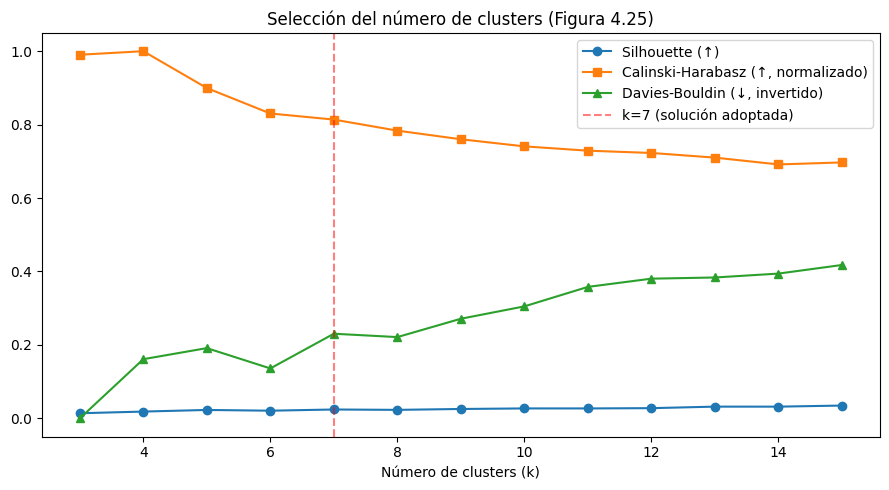

In [7]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_kselect.k, df_kselect.silhouette, "-o", label="Silhouette (↑)")
ax.plot(df_kselect.k, df_kselect.calinski_harabasz / df_kselect.calinski_harabasz.max(),
        "-s", label="Calinski-Harabasz (↑, normalizado)")
ax.plot(df_kselect.k, 1 - df_kselect.davies_bouldin / df_kselect.davies_bouldin.max(),
        "-^", label="Davies-Bouldin (↓, invertido)")
ax.axvline(7, color="red", linestyle="--", alpha=0.5, label="k=7 (solución adoptada)")
ax.set_xlabel("Número de clusters (k)")
ax.set_title("Selección del número de clusters (Figura 4.25)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS_DIR / "fig_4_25_k_selection.png", dpi=200)
plt.show()


### Justificación de k = 7

La combinación de las tres métricas identifica a **k = 7** como un punto de inflexión estructural:

- **Calinski-Harabasz** deja de descender de forma apreciable a partir de k=7 (se mantiene en ~3.00
  respecto de k=6, y no vuelve a mejorar en el resto del rango evaluado).
- **Davies-Bouldin** alcanza en k=7 un **mínimo local genuino**: mejor que en k=6 y que en k=8 (donde
  el índice se revierte antes de retomar su tendencia descendente).
- **Silhouette** registra en k=7 su primer valor claramente por encima del rango de ruido observado
  entre k=3 y k=6.

Esta convergencia simultánea de las tres métricas en un mismo valor de k —poco habitual en este tipo
de análisis— ofrece una base estadística más sólida que privilegiar un único índice de forma aislada
(p. ej., maximizar solo Silhouette, que en este corpus tiene baja potencia estadística dado el tamaño
moderado N=177 y el alto solapamiento temático inherente a artículos de una misma disciplina).


In [8]:

print(df_kselect[df_kselect.k.isin([6, 7, 8])].round(3).to_string(index=False))


 k  silhouette  calinski_harabasz  davies_bouldin
 6       0.021              2.909           5.275
 7       0.024              2.851           4.698
 8       0.023              2.745           4.754


## 5. Modelo final: K-means con k = 7

In [9]:

K_FINAL = 7
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=50, max_iter=1000)
labels = kmeans_final.fit_predict(Z)
df["cluster"] = labels

summary = (df.groupby("cluster")
             .agg(n_docs=("doc_id", "count"), year_min=("year", "min"), year_max=("year", "max"))
             .reset_index())
summary.to_csv(TABLES_DIR / "tabla_4_7_resumen_clusters.csv", index=False)
summary


,cluster,n_docs,year_min,year_max
0,0,20,2010,2024
1,1,42,2010,2025
2,2,32,2010,2025
3,3,50,2010,2025
4,4,11,2010,2025
5,5,15,2011,2022
6,6,7,2015,2023


## 6. Interpretación de clusters: términos representativos (Tabla 4.5)

In [10]:

def top_terms_by_cluster(X_tfidf, labels, vocab, topn=6):
    rows = []
    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        mean_vec = np.asarray(X_tfidf[idx].mean(axis=0)).ravel()
        top_idx = np.argsort(mean_vec)[::-1][:topn]
        rows.append({"cluster": c, **{f"T{i+1}": vocab[j] for i, j in enumerate(top_idx)}})
    return pd.DataFrame(rows)

df_top_terms = top_terms_by_cluster(X_tfidf, labels, vocab, topn=6)
df_top_terms.to_csv(TABLES_DIR / "tabla_4_5_terminos_representativos.csv", index=False)
df_top_terms


,cluster,T1,T2,T3,T4,T5,T6
0,0,skew,distribut,normal,skew normal,symmetr,normal distribut
1,1,model,bayesian,mix,time,linear,mix model
2,2,test,imag,valu,tabl,good,critic
3,3,distribut,model,likelihood,estim,paramet,maximum
4,4,spatial,spatial autocorrel,variabl,autocorrel,random,random variabl
5,5,estim,mean,popul,error,mean squar,sampl
6,6,chart,length,monitor,percentil,run length,shewhart


## 7. Artículos representativos por cluster (Tabla 4.6)

El artículo representativo de cada cluster es el más cercano al centroide en el espacio latente Z
(distancia euclídea), consistente con que el centroide de K-means es el estimador de mínimos
cuadrados de la posición media del cluster.


In [11]:

def representatives_by_cluster(Z, labels, df_meta):
    rows = []
    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        centroid = Z[idx].mean(axis=0, keepdims=True)
        # Distancia euclidea de CADA documento del cluster al centroide (no solo la minima):
        # pairwise_distances_argmin_min(centroid, Z[idx]) devuelve un unico valor (el mas
        # cercano), por lo que ordenar ese array de 1 elemento con argsort es un no-op que
        # termina seleccionando idx[0] (el primer documento por indice, no el mas cercano).
        dists = np.linalg.norm(Z[idx] - centroid, axis=1)
        order = np.argsort(dists)
        best = idx[order][0]
        rows.append({
            "cluster": c, "doc_id": df_meta.loc[best, "doc_id"],
            "year": df_meta.loc[best, "year"], "title": df_meta.loc[best, "title"],
        })
    return pd.DataFrame(rows)

df_representatives = representatives_by_cluster(Z, labels, df)
df_representatives.to_csv(TABLES_DIR / "tabla_4_6_articulos_representativos.csv", index=False)
df_representatives


,cluster,doc_id,year,title
0,0,109,2019,Linear regression models using finite mixtures...
1,1,67,2015,Bayesian analysis for a class of beta mixed mo...
2,2,164,2024,A new goodness-of-fit test for the Cauchy dist...
3,3,93,2017,A new extension of power Lindley distribution ...
4,4,147,2022,Spatial autocorrelation and unorthodox random ...
5,5,40,2013,Improved estimation of population mean using p...
6,6,71,2015,Burr Type-XII Percentile Control Charts


## 8. Validación de robustez: bootstrap re-clustering (ARI)

Se generan B=200 réplicas bootstrap del corpus (muestreo con reemplazo), se re-entrena K-means en
cada una, y se compara la partición resultante con la solución base mediante el **Adjusted Rand
Index (ARI)**, alineando etiquetas con el algoritmo húngaro para evitar el problema de *label
switching*.


In [12]:

def align_labels(y_true, y_pred, k):
    conf = np.zeros((k, k), dtype=int)
    for t, p in zip(y_true, y_pred):
        conf[int(t), int(p)] += 1
    row_ind, col_ind = linear_sum_assignment(conf.max() - conf)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[int(p)] for p in y_pred])

B = 200
N = len(labels)
rng = np.random.default_rng(RANDOM_STATE)
centroids0 = np.vstack([Z[labels == i].mean(axis=0) for i in range(K_FINAL)])

ari_rows, percl_rows = [], []
for b in range(1, B + 1):
    idx = rng.integers(0, N, size=N)
    km_b = KMeans(n_clusters=K_FINAL, n_init=20, max_iter=500, random_state=rng.integers(0, 10_000))
    km_b.fit(Z[idx])
    yb = align_labels(labels, km_b.predict(Z), K_FINAL)
    ari_rows.append({"replica": b, "ARI": adjusted_rand_score(labels, yb)})

    for i in range(K_FINAL):
        set0, setb = set(np.where(labels == i)[0]), set(np.where(yb == i)[0])
        inter, union = len(set0 & setb), len(set0 | setb)
        percl_rows.append({"cluster": i, "Jaccard": inter / union if union else np.nan})

df_ari = pd.DataFrame(ari_rows)
df_stability = pd.DataFrame(percl_rows).groupby("cluster").mean().reset_index()
df_ari.to_csv(TABLES_DIR / "bootstrap_ari_summary.csv", index=False)
df_stability.to_csv(TABLES_DIR / "cluster_stability.csv", index=False)

print(f"ARI mediana: {df_ari.ARI.median():.3f}  (IQR: {df_ari.ARI.quantile(.25):.3f}-{df_ari.ARI.quantile(.75):.3f})")
df_stability.round(3)


ARI mediana: 0.253  (IQR: 0.208-0.317)


,cluster,Jaccard
0,0,0.328
1,1,0.359
2,2,0.462
3,3,0.469
4,4,0.224
5,5,0.386
6,6,0.271


## 9. Comparación con métodos alternativos (DBSCAN, clustering jerárquico)

In [13]:

dbscan = DBSCAN(eps=5.0, min_samples=5)
labels_db = dbscan.fit_predict(Z)

hier = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
labels_hier = hier.fit_predict(Z)

df_compare = pd.DataFrame([
    {"algoritmo": "DBSCAN", "ARI_vs_kmeans": adjusted_rand_score(labels, labels_db),
     "n_clusters": len(set(labels_db)) - (1 if -1 in labels_db else 0)},
    {"algoritmo": "Jerárquico (Ward)", "ARI_vs_kmeans": adjusted_rand_score(labels, labels_hier),
     "n_clusters": len(set(labels_hier))},
])
df_compare.to_csv(TABLES_DIR / "comparacion_algoritmos.csv", index=False)
df_compare


,algoritmo,ARI_vs_kmeans,n_clusters
0,DBSCAN,0.000000,1
1,Jerárquico (Ward),0.336535,7


## 10. Evolución temporal por cluster (Tabla 4.8, Tabla 4.9)

In [14]:

df_valid_year = df.dropna(subset=["year"]).copy()
df_valid_year["year"] = df_valid_year["year"].astype(int)

tabla_year_cluster = pd.crosstab(df_valid_year["year"], df_valid_year["cluster"])
tabla_year_cluster.to_csv(TABLES_DIR / "tabla_4_8_cluster_por_anio.csv")

trend_rows = []
years_arr = tabla_year_cluster.index.to_numpy().reshape(-1, 1)
for c in tabla_year_cluster.columns:
    y = tabla_year_cluster[c].to_numpy()
    model = LinearRegression().fit(years_arr, y)
    trend_rows.append({
        "cluster": c, "pendiente": model.coef_[0],
        "R2": model.score(years_arr, y),
    })
df_trends = pd.DataFrame(trend_rows).sort_values("pendiente", ascending=False)
df_trends.to_csv(TABLES_DIR / "tabla_4_9_tendencias.csv", index=False)
df_trends.round(3)


,cluster,pendiente,R2
3,3,0.100,0.123
6,6,0.037,0.038
2,2,-0.065,0.034
4,4,-0.072,0.069
5,5,-0.072,0.104
1,1,-0.118,0.139
0,0,-0.171,0.202


## 11. Cruces geográficos e institucionales (Tabla 4.10, Tabla 4.11)

El país y la universidad se extraen del nivel de **autor** (lista anidada `Autores[i].pais` /
`Autores[i].universidad`), no de un campo a nivel de artículo — un punto importante, ya que una
implementación ingenua que busque `record["pais"]` directamente en la raíz del JSON no encontrará
nada y devolverá "N/D" para el 100% de los artículos.


In [15]:

def moda_no_nd(series):
    vals = [x for x in series if x and x != "N/D"]
    return pd.Series(vals).mode().iloc[0] if vals else "N/D"

aff_rows = []
for i, rec in enumerate(records):
    autores = rec.get("Autores") or []
    if not autores:
        aff_rows.append({"doc_id": i, "pais": "N/D", "universidad": "N/D"})
        continue
    for a in autores:
        aff_rows.append({
            "doc_id": i,
            "pais": a.get("pais") or "N/D",
            "universidad": a.get("universidad") or "N/D",
        })

df_aff = pd.DataFrame(aff_rows).groupby("doc_id").agg(
    pais=("pais", moda_no_nd), universidad=("universidad", moda_no_nd)
).reset_index()

df_geo = df_aff.merge(df[["doc_id", "cluster"]], on="doc_id")

tabla_pais = pd.crosstab(df_geo["pais"], df_geo["cluster"])
tabla_pais.to_csv(TABLES_DIR / "tabla_4_10_cluster_pais.csv")

top_univ = df_geo["universidad"].value_counts().head(10).index
tabla_univ = pd.crosstab(df_geo[df_geo.universidad.isin(top_univ)]["universidad"],
                          df_geo[df_geo.universidad.isin(top_univ)]["cluster"]).loc[top_univ]
tabla_univ.to_csv(TABLES_DIR / "tabla_4_11_cluster_universidad.csv")

print("Top 10 países por volumen:")
print(tabla_pais.sum(axis=1).sort_values(ascending=False).head(10))


Top 10 países por volumen:
pais
Brazil           66
India            16
Chile            13
United States    10
Italy             7
Algeria           6
Iran              6
Mexico            6
Colombia          4
Australia         3
dtype: int64


## Resumen

Este notebook reproduce de forma completa y reproducible el pipeline de clusterización temática
reportado en la Sección 4.4 de la tesis, con la solución final **k = 7**. Todas las tablas generadas
se guardan en `../results/tables/` y las figuras en `../results/figures/`, listas para su cita directa
en el documento.
